In [1]:
import sys
from pathlib import Path

# add parent folder to python path
sys.path.append(str(Path.cwd().parent))

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [3]:
import os
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
from utils import   show_images
from tqdm import tqdm
from data_handlers.datasets import UDAFrameDataset
from utils.file_management import serialize_config,get_version_folder
from utils.augmentation import Augmentations
from model import EncoderDecoder
import torchvision.utils as vutils


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

binary_mask = torch.load('cache/utils/binary_mask.pt').to(device)

In [4]:
root = 'cache/model_weights/supplementary_vector'
index_folder = get_version_folder(root)

In [5]:
config= {
    'lr': 1e-4,
    'epochs': 10,
    'batch_size' : 32,
    'transformations' :None,
    'model_path':os.path.join(index_folder,'model.pt'),
    'samples_path':os.path.join(index_folder,'samples'),
    'bottleneck_dim':64,
    'number_of_frames':1,
    'number_of_vectors':12,
    'number_of_vectorizers':2,
    'add_checkboard':False
}

config_json= serialize_config(config)
with open(os.path.join(index_folder,'config.json'),'w') as f:
    json.dump(config_json,f,indent=2)
os.mkdir(config['samples_path'])

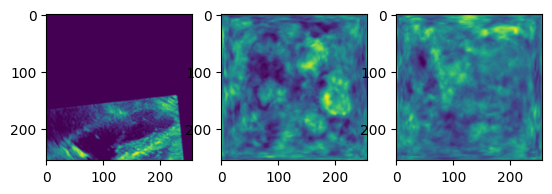

In [6]:
model = EncoderDecoder(bottleneck_dim=config['bottleneck_dim'],
                        number_of_vectors = config['number_of_vectors'],
                        number_of_vectorizers=  config['number_of_vectorizers'],
                        save_path = config['model_path']).to(device)

                 
optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

dataset = UDAFrameDataset(number_of_frames=config['number_of_frames'])
train_loader = torch.utils.data.DataLoader(dataset, batch_size=config['batch_size'], shuffle=True)

losses =[]

augmentations = Augmentations( degrees=180,
                                translate=(0.0, 0.5),
                                scale=(0.6, 1.8),
                                shear=30,
                                add_checkboard=config['add_checkboard'])
data = next(iter(train_loader))
data = augmentations(data)
data = data.to(device)[:,0]
with torch.no_grad():
    rec,seg= model(data)
show_images([data[0],rec[0]*seg[0],rec[1]*seg[1]])


In [7]:
epochs  =10
for epoch in range(epochs):
    loop = tqdm(train_loader,desc=f'Epoch {epoch}/{epochs}')
    for data in loop:
        data = augmentations(data)
        optimizer.zero_grad()
        frame = data[:,0].to(device)    
        rec,seg= model(frame)
       
        heads = seg.shape[1]
        
        loss = 0
        overlap_loss =0
        for i in range(heads):
            for j in range(i+1,heads):
                overlap_loss += (1/heads**2)*(seg[:,i]*seg[:,j]).mean()
        overlap_loss = 200 * overlap_loss 

        reconstruction = torch.sum(seg*rec,dim=1).unsqueeze(1)
        recon_loss = 20*F.mse_loss(reconstruction,frame)
        for i in range(rec.shape[1]):
            recon_loss += 10*F.mse_loss(rec[:,i].unsqueeze(1),frame)
        loss = recon_loss + overlap_loss

    
      
        loss.backward()
        optimizer.step()
        losses.append(loss.item()) 
        loop.set_postfix(recon_loss=recon_loss.item(),overlap_loss=overlap_loss.item())
    # torch.save(model.state_dict(), model.save_path)
    imgs_to_plot = torch.cat([
            data[:4,0].cpu(),           # Top row: Real
            seg[:4,:1].cpu(),  # Middle row: Reconstructed
            seg[:4,1:].cpu()        
    ], dim=0)
        
        
    # Create a grid natively on the tensσors
    grid = vutils.make_grid(imgs_to_plot, nrow=4)

    # 1. Save to disk (replaces plt.savefig)
    img_path = os.path.join(config['samples_path'],  f'{epoch}.png')
    vutils.save_image(grid, img_path)

Epoch 0/10:   2%|▏         | 29/1179 [00:10<06:57,  2.76it/s, overlap_loss=5.84, recon_loss=8.24]


KeyboardInterrupt: 

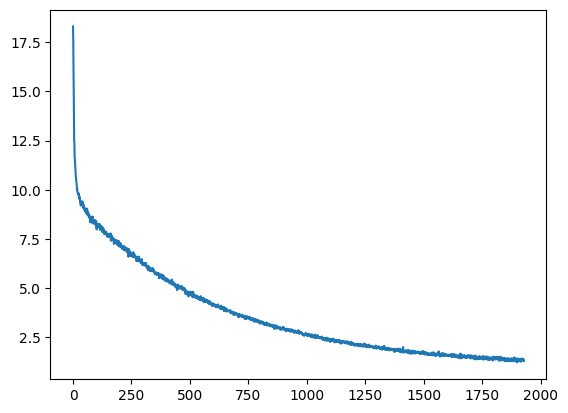

In [ ]:
plt.plot(losses)

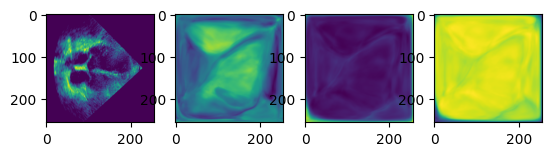

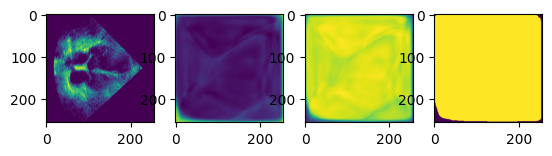

In [9]:
data = next(iter(train_loader))

frame = augmentations(data,train=False)[:,0].to(device)
with torch.no_grad():
    rec,seg= model(frame)
    reconstruction = torch.sum(seg*rec,dim=1).unsqueeze(1)
show_images([frame[0],reconstruction[0],seg[:,0],seg[:,1]])
show_images([frame[0],seg[:,0],seg[:,1],seg[:,1]>0.7])


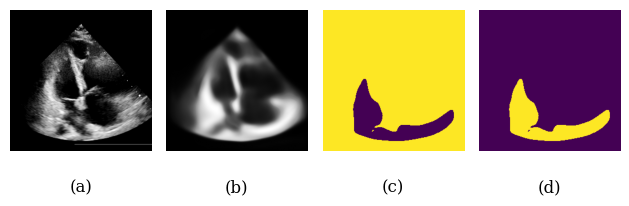

In [ ]:
data = next(iter(train_loader))

frame = augmentations(data,train=False)[:,0].to(device)
with torch.no_grad():
    rec,seg= model(frame)
    reconstruction = torch.sum(seg*rec,dim=1).unsqueeze(1)

fig,ax = plt.subplots(1,4)
x = frame[0,0].cpu().numpy()
x = np.rot90(x, 1)
ax[0].imshow(x, cmap='gray')
ax[0].axis('off')
ax[0].text(
        0.5, -0.2, '(a)',
        transform=ax[0].transAxes,
        fontname='serif',   # or 'Arial', 'Helvetica'
        ha='center', va='top',
        fontsize=12
    )
x = reconstruction[0,0].cpu().numpy()
x = np.rot90(x, 1)
ax[1].imshow(x, cmap='gray')
ax[1].axis('off')
ax[1].text(
        0.5, -0.2, '(b)',
        transform=ax[1].transAxes,
        fontname='serif',   # or 'Arial', 'Helvetica'
        ha='center', va='top',
        fontsize=12
    )
x = seg[0,0].cpu().numpy()
x = np.rot90(x>0.5, 1)
ax[2].imshow(x)
ax[2].axis('off')
ax[2].text(
        0.5, -0.2, '(c)',
        transform=ax[2].transAxes,
        fontname='serif',   # or 'Arial', 'Helvetica'
        ha='center', va='top',
        fontsize=12
    )
x = seg[0,1].cpu().numpy()
x = np.rot90(x, 1)

ax[3].imshow(x >0.5)
ax[3].axis('off')
ax[3].text(
        0.5, -0.2, '(d)',
        transform=ax[3].transAxes,
        fontname='serif',   # or 'Arial', 'Helvetica'
        ha='center', va='top',
        fontsize=12
    )
plt.tight_layout()

# bbox_inches='tight' is the key here. 
# pad_inches=0.01 removes the tiny white margin around the edges.
fig.savefig("non_checkboard.pdf", format='pdf', dpi=300, bbox_inches='tight', pad_inches=0.05)
